In [1]:
import numpy as np
import torch
import matplotlib
from matplotlib import pyplot as plt
import scipy as sc

from generator import GeneratorBuilder
from potential import WolfeQuapp, WolfeQuappBiased
from aimmd import AIMMDNetwork, AIMMDCommittorTrainer
from wq_estimate_committor import wq_order_param_circle, q_A_B_from_R
from util import ress, correlate
from tps import load_umbrella_sampling_samples, generate_path_to_state_brownian

import json
from tqdm.auto import tqdm

import os

TO_CM = 1/2.54
matplotlib.rcParams.update({'font.size': 10})
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 10
})

h = 4.0

q_A = q_A_B_from_R("A", 0.5, WolfeQuapp(h=h))
q_B = q_A_B_from_R("B", 0.5, WolfeQuapp(h=h))

param_dict= {"max": 2.3, "dx": 0.01, "ntrajectories" : 1000, "h": h, "qa": q_A, "qb": q_B, "target": "B", "timestep": 1e-2, "diffusioncoeff": 1.0, "orderparam": "circular"}

filename = "committor_estimates/wq"
for param_name, param in param_dict.items():
    filename += f"_{param_name}_{param}"
filename += ".csv"

loaded_committor_estimates = np.loadtxt(filename, delimiter=",")

side_length = int(np.sqrt(len(loaded_committor_estimates)))
sort_args = np.argsort(loaded_committor_estimates[:, 0]*side_length + loaded_committor_estimates[:, 1])

committor_estimates = loaded_committor_estimates[sort_args]

X = committor_estimates[:, 0].reshape(side_length, side_length).T[0].flatten()
Y = committor_estimates[:, 1].reshape(side_length, side_length).T[:, 0].flatten()

committor_values = committor_estimates[:, 2].reshape(side_length, side_length)
committor_values = sc.ndimage.gaussian_filter(committor_values, 5)

interp = sc.interpolate.RegularGridInterpolator((X, Y), committor_values, bounds_error=False)

def cv_function(coords):
    coords = np.where(np.abs(coords) < 2.3, coords, np.sign(coords)*2.299)
    return interp(coords)

unwrapped_potential = WolfeQuappBiased(h=h, k_bias=300, cv_function=cv_function)
cv_gradient_function = unwrapped_potential.cv_gradient

class CVFunctionAutograd(torch.autograd.Function):

    @staticmethod
    def forward(ctx, input):
        ctx.save_for_backward(input)

        coords = input.detach().cpu().numpy()
        cv_values = cv_function(coords)

        return torch.from_numpy(cv_values).to(input.device)

    @staticmethod
    def backward(ctx, grad_output):
        input, = ctx.saved_tensors

        coords = input.detach().cpu().numpy()
        grad = torch.from_numpy(cv_gradient_function(coords)).to(input.device)

        return grad*grad_output[..., None]
    
def cv_function_wrapper(coords):
    return CVFunctionAutograd.apply(coords)

potential = WolfeQuappBiased(h=h, k_bias=300, cv_function=cv_function_wrapper)

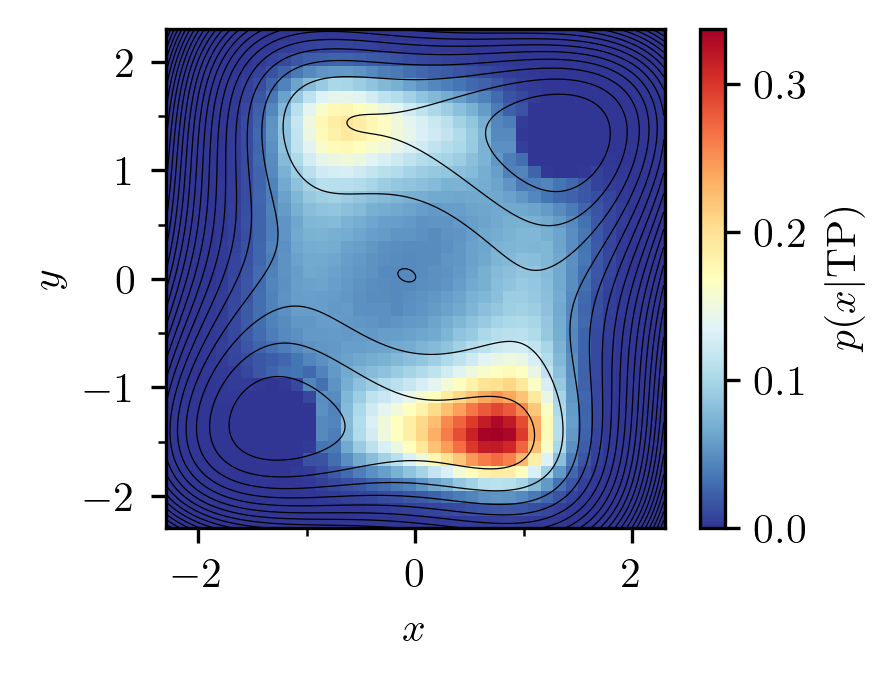

In [3]:
bins = 40
bin_edges = np.linspace(-2.3, 2.3, bins + 1)
bin_centers = (bin_edges[1:] + bin_edges[:-1])/2

reference_paths = []
with open("samples/wq_tps_nsamples_25000_nout_500_trajectoryoutfrequency_10_max_2.3_h_4.0_qa_-8.20849986238988_qb_8.20849986238988_timestep_0.001_diffusioncoeff_1.0_orderparam_circular.json", "r") as file:
    for line in file.read().splitlines():
        reference_paths.append(np.array(json.loads(line)))

x_data = np.array([item for path in reference_paths for item in path[:, 0]]).flatten()
y_data = np.array([item for path in reference_paths for item in path[:, 1]]).flatten()

reference_path_lengths = np.array(list(map(len, reference_paths)))

reference_p_x_TP = np.histogram2d(x_data, y_data, bins=bin_edges, density=True)[0]

fig, ax = plt.subplots(1, 1, figsize=(8*TO_CM, 6*TO_CM), dpi=300)

potential.plot_PES(fig, ax, title="", fill=False)

image = ax.imshow(reference_p_x_TP.T, cmap="RdYlBu_r", vmin=0, origin="lower", extent=(bin_edges[0], bin_edges[-1], bin_edges[0], bin_edges[-1]), aspect="auto")
cbar = fig.colorbar(image, ax=ax)
cbar.set_label(r"$p(x | \mathrm{TP})$")

ax.set_xlim((-2.3, 2.3))
ax.set_ylim((-2.3, 2.3))

ax.set_aspect('equal')

ax.set_xlabel("$x$")
ax.set_ylabel("$y$")

fig.tight_layout()

plt.show()

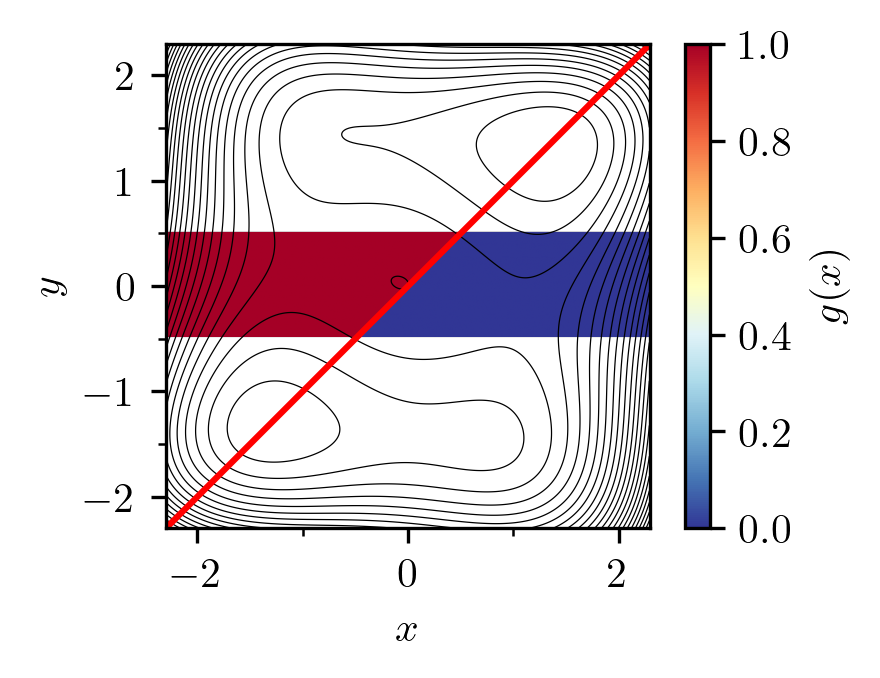

In [4]:
def g(path):
    mask = np.abs(path[..., 1]) < 0.5
    path = path[mask]

    if len(path) == 0:
        return np.nan

    projection = path[..., 1] - path[..., 0]

    return np.round((np.sign(np.mean(projection)) + 1) / 2)

X, Y = np.meshgrid(np.arange(-2.3, 2.3, 0.01), np.arange(-2.3, 2.3, 0.01))
grid = np.array([[X[i, j], Y[i, j]] for i in range(X.shape[0]) for j in range(X.shape[1])])
g_values = np.array([g(grid_point) for grid_point in grid]).reshape(X.shape)

fig, ax = plt.subplots(1, 1, figsize=(8*TO_CM, 6*TO_CM), dpi=300)

unwrapped_potential.plot_PES(fig, ax, fill=False)

image = ax.imshow(g_values, cmap="RdYlBu_r", vmin=0, vmax=1, origin="lower", extent=(-2.3, 2.3, -2.3, 2.3), aspect="auto")

ax.plot([-2.3, 2.3], [-2.3, 2.3], color="red")

cbar = fig.colorbar(image, ax=ax)
cbar.set_label(r"$g(x)$")

ax.set_xlim((-2.3, 2.3))
ax.set_ylim((-2.3, 2.3))

ax.set_aspect('equal')

ax.set_xlabel("$x$")
ax.set_ylabel("$y$")

fig.tight_layout()

plt.show()

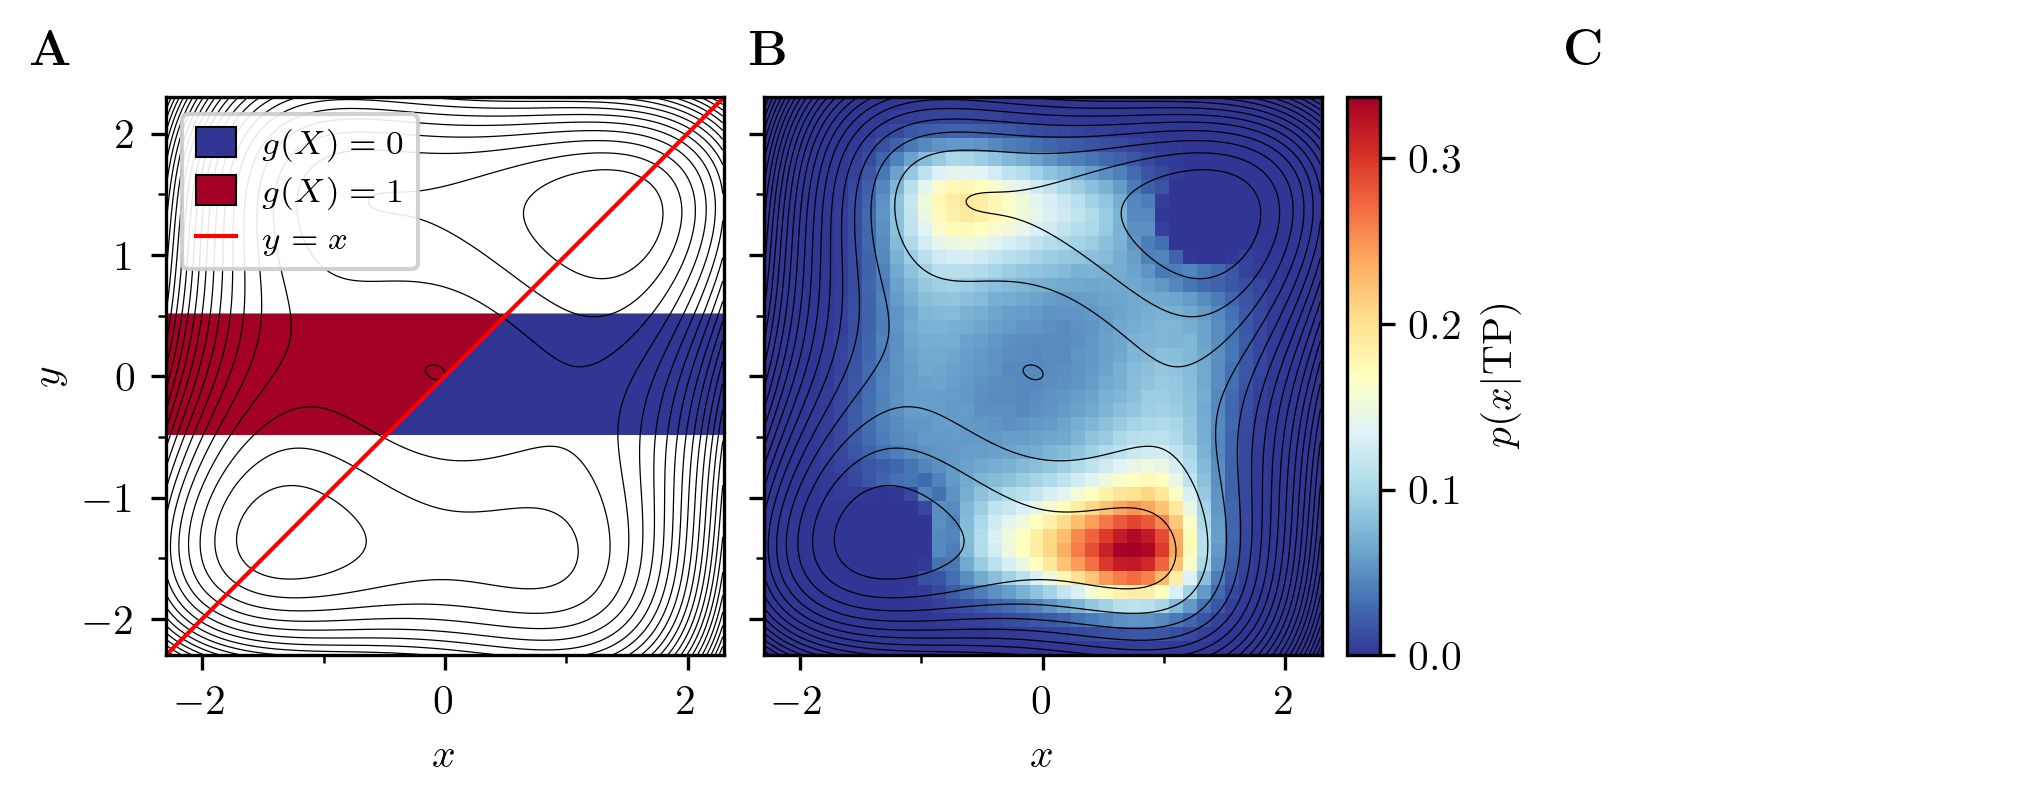

In [7]:
FIGURE_WIDTH = 17
FIGURE_HEIGHT = 6.3
LABEL_STRIP = 0.45
PANEL_C_WIDTH = 0.8

fig = plt.figure(figsize=(FIGURE_WIDTH*TO_CM, FIGURE_HEIGHT*TO_CM), dpi=300, layout="constrained")
fig.get_layout_engine().set(rect=(0, 0, 1, 1 - LABEL_STRIP/FIGURE_HEIGHT))


grid = fig.add_gridspec(1, 4, width_ratios=[1, 1, 0.06, PANEL_C_WIDTH])

ax_g = fig.add_subplot(grid[0, 0])
ax_p = fig.add_subplot(grid[0, 1], sharey=ax_g)
cax = fig.add_subplot(grid[0, 2])

ax_c = fig.add_subplot(grid[0, 3])
ax_c.set_axis_off()

unwrapped_potential.plot_PES(fig, ax_g, fill=False)

ax_g.imshow(g_values, cmap="RdYlBu_r", vmin=0, vmax=1, origin="lower",
            extent=(-2.3, 2.3, -2.3, 2.3), aspect="auto")
line = ax_g.plot([-2.3, 2.3], [-2.3, 2.3], color="red", label="$y = x$", lw=1)[0]

colormap = matplotlib.colormaps["RdYlBu_r"]
handles = [matplotlib.patches.Patch(facecolor=colormap(value), edgecolor="black", linewidth=0.5,
                                    label=rf"$g(X) = {value:.0f}$") for value in (0.0, 1.0)]

handles.append(line)

ax_g.legend(handles=handles, loc="upper left", fontsize=8, framealpha=0.9, borderpad=0.4,
            handlelength=1.2, handleheight=1.0, labelspacing=0.4)

potential.plot_PES(fig, ax_p, title="", fill=False)

image = ax_p.imshow(reference_p_x_TP.T, cmap="RdYlBu_r", vmin=0, origin="lower",
                    extent=(bin_edges[0], bin_edges[-1], bin_edges[0], bin_edges[-1]),
                    aspect="auto")

cbar = fig.colorbar(image, cax=cax)
cbar.set_label(r"$p(x | \mathrm{TP})$")

for ax in (ax_g, ax_p):
    ax.set_xlim((-2.3, 2.3))
    ax.set_ylim((-2.3, 2.3))
    ax.set_aspect('equal')
    ax.set_xlabel("$x$")

ax_g.set_ylabel("$y$")
ax_p.set_ylabel("")
ax_p.tick_params(labelleft=False)

fig.canvas.draw()
fig.set_layout_engine("none")

box_p, box_c = ax_p.get_position(), cax.get_position()
cax.set_position([box_c.x0, box_p.y0, box_c.width, box_p.height])

for ax, panel in ((ax_g, "A"), (ax_p, "B"), (ax_c, "C")):
    bbox = ax.get_tightbbox().transformed(fig.transFigure.inverted())
    fig.text(bbox.x0, 1.0, r"\textbf{" + panel + "}", horizontalalignment='left',
             verticalalignment='top', fontsize=12)

plt.show()